# Parte 2: Experimentación de Modelado y Ensambles

En esta sección tomarán los aprendizajes del EDA para construir pipelines sólidos (Scikit-Learn). Luego experimentarán con varios algoritmos avanzados priorizados en árboles y ensambles.

## Pasos Clave
1. **Split Temporal**: Asegurar que Train (2015-2023), Validación (2024), Test (2025).
2. **Pipelines**: Creación ágil del Feature Engineering (e.j., escalado, imputación, variables dummy / target encoding).
3. **Entrenamiento**: Evaluación base usando Regresión Lineal, Voting, y comparar Bagging vs Pasting.
4. **Boosting**: Implementar CV y GridSearch para AdaBoost, GBDT, XGBoost, LightGBM, CatBoost.
5. **Selección**: Reporte final de RMSE/MAE en Train/Val de todos para encontrar al ganador. Solo con el ganador evaluar en Test (2025).

In [2]:
import os
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import snowflake.connector

load_dotenv()

def get_conn():
    return snowflake.connector.connect(
        account=os.environ['SNOWFLAKE_ACCOUNT'],
        user=os.environ['SNOWFLAKE_USER'],
        password=os.environ['SNOWFLAKE_PASSWORD'],
        database=os.environ['SNOWFLAKE_DATABASE'],
        warehouse=os.environ['SNOWFLAKE_WAREHOUSE'],
        schema=os.environ['SNOWFLAKE_SCHEMA'],
        role=os.environ.get('SNOWFLAKE_ROLE'),
    )

def query(sql: str) -> pd.DataFrame:
    conn = get_conn()
    try:
        return pd.read_sql(sql, conn)
    finally:
        conn.close()

## Selección de samples

In [1]:
# TRAIN: muestreo ESTRATIFICADO por (SERVICE_TYPE, YEAR).
#
# El EDA (notebook 01) mostró dos sesgos fuertes en TRAIN_FE:
#   1. Yellow tiene ~10x más volumen que Green.
#   2. Los años pre-COVID (2015-2019) dominan sobre los recientes (2020-2023),
#      que son justamente los más parecidos a 2024 (val) y 2025 (test).
#
# Un TABLESAMPLE uniforme reproduce ambos sesgos: el modelo entrena casi solo
# con Yellow pre-COVID. Aquí asignamos un cupo igual a cada combinación
# (servicio, año) usando una ventana QUALIFY ROW_NUMBER() -- es un SELECT puro,
# NO crea ni modifica tablas en Snowflake. RANDOM(42) fija la semilla.
#
# 18 estratos (2015-2023 x {yellow, green}) x 35k = ~630k filas, similar al
# 0.1% que usábamos antes pero ahora balanceado. Si un estrato tiene menos
# filas que el cupo, se devuelven todas (no rellena ni duplica).
#
# VAL y TEST se mantienen con TABLESAMPLE uniforme: la evaluación debe
# reflejar la distribución real del año futuro, no una balanceada artificial.
#
# CACHE: la query estratificada tarda ~30 min, así que persistimos el sample
# (train y val) en data/interim/ como parquet. Re-ejecuciones del notebook
# leen del parquet local en vez de volver a Snowflake. Para forzar refresh,
# borrar el parquet o setear FORCE_REFRESH = True.

from pathlib import Path
import pandas as pd

INTERIM_DIR = Path("../data/interim")
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PER_STRATUM = 35_000
TRAIN_PARQUET = INTERIM_DIR / f"train_fe_stratified_{TRAIN_PER_STRATUM}.parquet"
VAL_PARQUET = INTERIM_DIR / "val_fe_sample_1pct.parquet"
FORCE_REFRESH = False

if TRAIN_PARQUET.exists() and not FORCE_REFRESH:
    print(f"[cache] cargando train desde {TRAIN_PARQUET}")
    train_df = pd.read_parquet(TRAIN_PARQUET)
else:
    print("[snowflake] descargando train estratificado (~30 min)...")
    train_df = query(f"""
        SELECT *
        FROM ANALYTICS.TRAIN_FE
        QUALIFY ROW_NUMBER() OVER (
            PARTITION BY SERVICE_TYPE, YEAR
            ORDER BY RANDOM(42)
        ) <= {TRAIN_PER_STRATUM}
    """)
    train_df.to_parquet(TRAIN_PARQUET, index=False)
    print(f"[cache] guardado train -> {TRAIN_PARQUET}")

if VAL_PARQUET.exists() and not FORCE_REFRESH:
    print(f"[cache] cargando val desde {VAL_PARQUET}")
    val_df = pd.read_parquet(VAL_PARQUET)
else:
    print("[snowflake] descargando val sample...")
    val_df = query("""
        SELECT *
        FROM ANALYTICS.VAL_FE
        TABLESAMPLE (1)
    """)
    val_df.to_parquet(VAL_PARQUET, index=False)
    print(f"[cache] guardado val -> {VAL_PARQUET}")

print(f"\ntrain_df: {len(train_df):,} filas")
print(f"val_df:   {len(val_df):,} filas")
print("\nDistribución de TRAIN por estrato (SERVICE_TYPE x YEAR):")
print(
    train_df.groupby(["SERVICE_TYPE", "YEAR"])
    .size()
    .reset_index(name="rows")
    .to_string(index=False)
)

[cache] cargando train desde ../data/interim/train_fe_stratified_35000.parquet
[cache] cargando val desde ../data/interim/val_fe_sample_1pct.parquet

train_df: 630,000 filas
val_df:   360,939 filas

Distribución de TRAIN por estrato (SERVICE_TYPE x YEAR):
SERVICE_TYPE  YEAR  rows
       green  2015 35000
       green  2016 35000
       green  2017 35000
       green  2018 35000
       green  2019 35000
       green  2020 35000
       green  2021 35000
       green  2022 35000
       green  2023 35000
      yellow  2015 35000
      yellow  2016 35000
      yellow  2017 35000
      yellow  2018 35000
      yellow  2019 35000
      yellow  2020 35000
      yellow  2021 35000
      yellow  2022 35000
      yellow  2023 35000


### Hacer DROP de columnas determinadas en anteriores notebooks para evitar leakage

In [4]:
TARGET = 'FARE_AMOUNT'
DROP_COLS = [
    # target
    'FARE_AMOUNT',

    # leakage
    'DROPOFF_DATETIME',
    'DROPOFF_DATE',
    'DROPOFF_HOUR',
    'TRIP_DURATION_MIN',
    'AVG_SPEED_MPH',
    'TIP_AMOUNT',
    'TIP_PCT',
    'EXTRA',
    'MTA_TAX',
    'TOLLS_AMOUNT',
    'IMPROVEMENT_SURCHARGE',
    'CONGESTION_SURCHARGE',
    'AIRPORT_FEE',
    'EHAIL_FEE',
    'TOTAL_AMOUNT',

    # metadata / linaje
    'RUN_ID',
    'SOURCE_YEAR',
    'SOURCE_MONTH',
    'SOURCE_PATH',
    'INGESTED_AT_UTC',

    # datetime crudo, mejor usar columnas derivadas
    'PICKUP_DATETIME',
    'PICKUP_DATE'
]

In [5]:
X_train = train_df.drop(columns=[c for c in DROP_COLS if c in train_df.columns])
y_train = train_df[TARGET]

X_val = val_df.drop(columns=[c for c in DROP_COLS if c in val_df.columns])
y_val = val_df[TARGET]

In [6]:
import numpy as np

# Asegurar que X_val tenga exactamente las mismas columnas que X_train
X_val = X_val[X_train.columns]

# Columnas textuales redundantes que ya tienen una versión codificada
REDUNDANT_TEXT_COLS = [
    'VENDOR_NAME',
    'PU_ZONE',
    'DO_ZONE',
    'RATE_CODE_DESC',
    'PAYMENT_TYPE_DESC'
]

X_train = X_train.drop(columns=[c for c in REDUNDANT_TEXT_COLS if c in X_train.columns])
X_val = X_val.drop(columns=[c for c in REDUNDANT_TEXT_COLS if c in X_val.columns])

# 1. Detectar columnas categóricas por tipo de dato
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# 2. Detectar columnas numéricas
numeric_candidate_features = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

# 3. Columnas numéricas que realmente son categóricas por ser IDs, códigos o tipos
categorical_name_patterns = [
    "ID",
    "TYPE",
    "CODE",
    "FLAG",
    "SERVICE"
]

numeric_but_categorical = [
    col for col in numeric_candidate_features
    if any(pattern in col.upper() for pattern in categorical_name_patterns)
]

# 4. Detectar columnas binarias 0/1
binary_features = []

for col in numeric_candidate_features:
    if col not in numeric_but_categorical:
        unique_values = set(X_train[col].dropna().unique())
        if unique_values.issubset({0, 1}):
            binary_features.append(col)

# 5. Las numéricas finales son las numéricas que no son categóricas ni binarias
numeric_features = [
    col for col in numeric_candidate_features
    if col not in numeric_but_categorical
    and col not in binary_features
]

# 6. Agregar las numéricas categóricas a las categóricas finales
categorical_features = categorical_features + numeric_but_categorical

# 7. Quitar duplicados por seguridad
numeric_features = list(dict.fromkeys(numeric_features))
binary_features = list(dict.fromkeys(binary_features))
categorical_features = list(dict.fromkeys(categorical_features))

print("Numeric features:")
print(numeric_features)

print("\nBinary features:")
print(binary_features)

print("\nCategorical features:")
print(categorical_features)

print("\nCantidad numéricas:", len(numeric_features))
print("Cantidad binarias:", len(binary_features))
print("Cantidad categóricas:", len(categorical_features))

Numeric features:
['PICKUP_HOUR', 'DAY_OF_WEEK', 'MONTH', 'YEAR', 'PASSENGER_COUNT', 'TRIP_DISTANCE', 'TIME_OF_DAY', 'WEEK_OF_YEAR', 'QUARTER', 'DIST_X_RUSH']

Binary features:
['IS_RUSH_HOUR', 'IS_WEEKEND', 'IS_LATE_NIGHT', 'IS_AIRPORT_PU', 'IS_AIRPORT_DO', 'IS_AIRPORT_TRIP', 'SAME_BOROUGH', 'PU_IS_MANHATTAN', 'DO_IS_MANHATTAN', 'RUSH_AIRPORT', 'LATE_NIGHT_WEEKEND']

Categorical features:
['SERVICE_TYPE', 'PU_BOROUGH', 'DO_BOROUGH', 'STORE_AND_FWD_FLAG', 'VENDOR_ID', 'PU_LOCATION_ID', 'DO_LOCATION_ID', 'RATE_CODE_ID', 'PAYMENT_TYPE', 'TRIP_TYPE']

Cantidad numéricas: 10
Cantidad binarias: 11
Cantidad categóricas: 10


In [7]:
selected_features = numeric_features + binary_features + categorical_features

print("Columnas en X_train:", len(X_train.columns))
print("Columnas seleccionadas:", len(selected_features))

missing_from_selection = [col for col in X_train.columns if col not in selected_features]
missing_from_X_train = [col for col in selected_features if col not in X_train.columns]

print("\nColumnas de X_train no seleccionadas:")
print(missing_from_selection)

print("\nColumnas seleccionadas que no están en X_train:")
print(missing_from_X_train)


Columnas en X_train: 31
Columnas seleccionadas: 31

Columnas de X_train no seleccionadas:
[]

Columnas seleccionadas que no están en X_train:
[]


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Pipeline para variables numéricas continuas
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline para variables binarias 0/1
binary_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

# Pipeline para variables categóricas
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])

# Preprocesador general
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("bin", binary_pipeline, binary_features),
        ("cat", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

In [9]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['PICKUP_HOUR', 'DAY_OF_WEEK', 'MONTH', 'YEAR',
                                  'PASSENGER_COUNT', 'TRIP_DISTANCE',
                                  'TIME_OF_DAY', 'WEEK_OF_YEAR', 'QUARTER',
                                  'DIST_X_RUSH']),
                                ('bin',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['IS_RUSH_...
                                  'PU_IS_MANHATTAN', 'DO_IS_MANHATTAN',
                                  'RUSH_AIRPORT', 'LATE_NIGHT_WEEKEND']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['SERVICE_TYPE', 'PU_BOROUGH', 'DO_BOROUGH',
                                  'STORE_AND_FWD_FLAG', 'VENDOR_ID',
                                  'PU_LOCATION_ID', 'DO_LOCATION_ID',
                                  'RATE_CODE_ID', 'PAYMENT_TYPE',
                                  'TRIP_TYPE'])])

In [10]:
import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def evaluate_model(name, model, X_train, y_train, X_val, y_val):
    """
    Trains a model inside a preprocessing pipeline and evaluates it
    on both training and validation data.

    Parameters
    ----------
    name : str
        Model name.
    model : sklearn-compatible estimator
        Regression model to train.
    X_train : pd.DataFrame
        Training features.
    y_train : pd.Series
        Training target.
    X_val : pd.DataFrame
        Validation features.
    y_val : pd.Series
        Validation target.

    Returns
    -------
    dict
        Dictionary containing model metrics and the trained pipeline.
    """

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    start_time = time.time()

    pipeline.fit(X_train, y_train)

    train_time = time.time() - start_time

    train_preds = pipeline.predict(X_train)
    val_preds = pipeline.predict(X_val)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))

    train_mae = mean_absolute_error(y_train, train_preds)
    val_mae = mean_absolute_error(y_val, val_preds)

    train_r2 = r2_score(y_train, train_preds)
    val_r2 = r2_score(y_val, val_preds)

    result = {
        "model_name": name,
        "train_rmse": train_rmse,
        "val_rmse": val_rmse,
        "train_mae": train_mae,
        "val_mae": val_mae,
        "train_r2": train_r2,
        "val_r2": val_r2,
        "train_time_sec": train_time,
        "pipeline": pipeline
    }

    return result

In [11]:
evaluate_model

<function __main__.evaluate_model(name, model, X_train, y_train, X_val, y_val)>

## Modelos base para comparación y comprobación de funcionamient


In [12]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

baseline_models = {
    "Dummy Mean": DummyRegressor(strategy="mean"),
    "Linear Regression": LinearRegression()
}

baseline_results = []

for name, model in baseline_models.items():
    print(f"Training {name}...")

    result = evaluate_model(
        name=name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val
    )

    baseline_results.append(result)

    print(f"{name} validation RMSE: {result['val_rmse']:.4f}")
    print(f"{name} validation MAE: {result['val_mae']:.4f}")
    print(f"{name} validation R2: {result['val_r2']:.4f}")
    print("-" * 50)

Training Dummy Mean...
Dummy Mean validation RMSE: 18.8693
Dummy Mean validation MAE: 10.4297
Dummy Mean validation R2: -0.1274
--------------------------------------------------
Training Linear Regression...
Linear Regression validation RMSE: 7.2129
Linear Regression validation MAE: 4.3330
Linear Regression validation R2: 0.8353
--------------------------------------------------


In [13]:
baseline_results_df = pd.DataFrame([
    {k: v for k, v in result.items() if k != "pipeline"}
    for result in baseline_results
]).sort_values("val_rmse")

baseline_results_df

,model_name,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2,train_time_sec
1,Linear Regression,3.380939,7.212935,1.901466,4.332975,0.912293,0.835264,46.010662
0,Dummy Mean,11.416143,18.869289,7.381383,10.429732,0.000000,-0.127396,4.627931


### Empezar a guardar todos los resultados para comparación al final

In [14]:
all_results = baseline_results.copy()

#### Entrenar modelos tipo bagging


### Bagging y Pasting 

Ambods baggins y pasting fueron entrenados con la misma configuración

- Estimador base: `DecisionTreeRegressor`
- `n_estimators = 20`
- `max_depth = 10`
- `min_samples_leaf = 20`
- `max_samples = 0.7`
- `random_state = 42`
- `n_jobs = -1`

La diferencia entre ambos modelos es la estrategia de sampling:

- Bagging Regressor: `bootstrap = True`
- Pasting Regressor: `bootstrap = False`

In [15]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=20,
        random_state=42
    ),
    n_estimators=20,
    max_samples=0.7,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

pasting_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=20,
        random_state=42
    ),
    n_estimators=20,
    max_samples=0.7,
    bootstrap=False,
    n_jobs=-1,
    random_state=42
)

bagging_pasting_models = {
    "Bagging Regressor": bagging_model,
    "Pasting Regressor": pasting_model
}

for name, model in bagging_pasting_models.items():
    print(f"Training {name}...")

    result = evaluate_model(
        name=name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val
    )

    all_results.append(result)

    print(f"{name} validation RMSE: {result['val_rmse']:.4f}")
    print(f"{name} validation MAE: {result['val_mae']:.4f}")
    print(f"{name} validation R2: {result['val_r2']:.4f}")
    print(f"Training time: {result['train_time_sec']:.2f} seconds")
    print("-" * 50)

Training Bagging Regressor...
Bagging Regressor validation RMSE: 4.8453
Bagging Regressor validation MAE: 2.4587
Bagging Regressor validation R2: 0.9257
Training time: 171.67 seconds
--------------------------------------------------
Training Pasting Regressor...
Pasting Regressor validation RMSE: 4.7874
Pasting Regressor validation MAE: 2.4463
Pasting Regressor validation R2: 0.9274
Training time: 219.90 seconds
--------------------------------------------------


In [16]:
all_results_df = pd.DataFrame([
    {k: v for k, v in result.items() if k != "pipeline"}
    for result in all_results
]).sort_values("val_rmse")

all_results_df

,model_name,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2,train_time_sec
3,Pasting Regressor,2.583925,4.787446,1.486539,2.446346,0.948770,0.927427,219.901020
2,Bagging Regressor,2.606859,4.845333,1.484564,2.458680,0.947857,0.925662,171.666829
1,Linear Regression,3.380939,7.212935,1.901466,4.332975,0.912293,0.835264,46.010662
0,Dummy Mean,11.416143,18.869289,7.381383,10.429732,0.000000,-0.127396,4.627931


### Voting Regressor 

El modelo `VotingRegressor` combina varios modelos base y promedia sus predicciones para obtener una predicción final más estable.

En este experimento se usaron tres modelos base:

1. `Ridge Regression`
   - `alpha = 1.0`
   - Sirve como modelo lineal regularizado.

2. `RandomForestRegressor`
   - `n_estimators = 50`
   - `max_depth = 12`
   - `min_samples_leaf = 20`
   - `random_state = 42`
   - `n_jobs = -1`

3. `ExtraTreesRegressor`
   - `n_estimators = 50`
   - `max_depth = 12`
   - `min_samples_leaf = 20`
   - `random_state = 42`
   - `n_jobs = -1`

La diferencia principal entre `RandomForestRegressor` y `ExtraTreesRegressor` es que `ExtraTreesRegressor` introduce más aleatoriedad al seleccionar divisiones en los árboles, lo que puede reducir varianza y mejorar generalización.

In [17]:
from sklearn.ensemble import VotingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge

voting_model = VotingRegressor(
    estimators=[
        ("ridge", Ridge(alpha=1.0)),
        ("random_forest", RandomForestRegressor(
            n_estimators=50,
            max_depth=12,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1
        )),
        ("extra_trees", ExtraTreesRegressor(
            n_estimators=50,
            max_depth=12,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Training Voting Regressor...")

voting_result = evaluate_model(
    name="Voting Regressor",
    model=voting_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

all_results.append(voting_result)

print(f"Voting Regressor validation RMSE: {voting_result['val_rmse']:.4f}")
print(f"Voting Regressor validation MAE: {voting_result['val_mae']:.4f}")
print(f"Voting Regressor validation R2: {voting_result['val_r2']:.4f}")
print(f"Training time: {voting_result['train_time_sec']:.2f} seconds")
print("-" * 50)

Training Voting Regressor...
Voting Regressor validation RMSE: 5.1146
Voting Regressor validation MAE: 2.7808
Voting Regressor validation R2: 0.9172
Training time: 1174.38 seconds
--------------------------------------------------


In [18]:
all_results_df = pd.DataFrame([
    {k: v for k, v in result.items() if k != "pipeline"}
    for result in all_results
]).sort_values("val_rmse")

all_results_df

,model_name,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2,train_time_sec
3,Pasting Regressor,2.583925,4.787446,1.486539,2.446346,0.948770,0.927427,219.901020
2,Bagging Regressor,2.606859,4.845333,1.484564,2.458680,0.947857,0.925662,171.666829
4,Voting Regressor,2.614956,5.114561,1.536312,2.780837,0.947533,0.917171,1174.378890
1,Linear Regression,3.380939,7.212935,1.901466,4.332975,0.912293,0.835264,46.010662
0,Dummy Mean,11.416143,18.869289,7.381383,10.429732,0.000000,-0.127396,4.627931


### AdaBoost Regressor: búsqueda de hiperparámetros con submuestra

En esta sección se realiza una búsqueda de hiperparámetros para `AdaBoostRegressor`.

AdaBoost suele explicarse usando árboles muy simples llamados *decision stumps*, donde `max_depth = 1`. Sin embargo, en problemas de regresión puede ser útil probar árboles base ligeramente más profundos. Por eso, se evaluarán diferentes valores de `max_depth`.

Para reducir el costo computacional, el tuning se hará sobre una submuestra representativa de entrenamiento y validación. Esto sigue la lógica del proyecto, ya que el README indica que no se debe cargar ni procesar todo el dataset localmente, sino usar muestras, lotes u out-of-core training para la experimentación.

La selección de hiperparámetros se hará usando RMSE sobre el conjunto de validación. El conjunto de test no se usa en esta etapa.

In [25]:
# Tamaños controlados para tuning
TUNE_TRAIN_SIZE = min(500_000, len(X_train))
TUNE_VAL_SIZE = min(100_000, len(X_val))

X_train_tune = X_train.sample(
    n=TUNE_TRAIN_SIZE,
    random_state=42
)

y_train_tune = y_train.loc[X_train_tune.index]

X_val_tune = X_val.sample(
    n=TUNE_VAL_SIZE,
    random_state=42
)

y_val_tune = y_val.loc[X_val_tune.index]

# Resetear índices para evitar problemas al concatenar
X_train_tune = X_train_tune.reset_index(drop=True)
y_train_tune = y_train_tune.reset_index(drop=True)

X_val_tune = X_val_tune.reset_index(drop=True)
y_val_tune = y_val_tune.reset_index(drop=True)

print("X_train_tune shape:", X_train_tune.shape)
print("y_train_tune shape:", y_train_tune.shape)
print("X_val_tune shape:", X_val_tune.shape)
print("y_val_tune shape:", y_val_tune.shape)

X_train_tune shape: (500000, 31)
y_train_tune shape: (500000,)
X_val_tune shape: (100000, 31)
y_val_tune shape: (100000,)


In [26]:
import time

print("Fitting preprocessor once for AdaBoost tuning...")

start_time = time.time()

X_train_tune_processed = preprocessor.fit_transform(X_train_tune)
X_val_tune_processed = preprocessor.transform(X_val_tune)

preprocessing_time = time.time() - start_time

print("Preprocessing completed.")
print(f"Preprocessing time: {preprocessing_time:.2f} seconds")
print("X_train_tune_processed shape:", X_train_tune_processed.shape)
print("X_val_tune_processed shape:", X_val_tune_processed.shape)

Fitting preprocessor once for AdaBoost tuning...
Preprocessing completed.
Preprocessing time: 4.60 seconds
X_train_tune_processed shape: (500000, 566)
X_val_tune_processed shape: (100000, 566)


In [29]:
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.model_selection import PredefinedSplit

# Unir train y validation ya preprocesados
if sparse.issparse(X_train_tune_processed):
    X_search_tune_processed = sparse.vstack([
        X_train_tune_processed,
        X_val_tune_processed
    ])
else:
    X_search_tune_processed = np.vstack([
        X_train_tune_processed,
        X_val_tune_processed
    ])

y_search_tune_processed = pd.concat(
    [y_train_tune, y_val_tune],
    axis=0
).reset_index(drop=True)

# -1 = entrenamiento
#  0 = validación
test_fold_tune = [-1] * X_train_tune_processed.shape[0] + [0] * X_val_tune_processed.shape[0]

predefined_split_tune = PredefinedSplit(test_fold=test_fold_tune)

print("X_search_tune_processed shape:", X_search_tune_processed.shape)
print("y_search_tune_processed shape:", y_search_tune_processed.shape)
print("Training rows:", X_train_tune_processed.shape[0])
print("Validation rows:", X_val_tune_processed.shape[0])

X_search_tune_processed shape: (600000, 566)
y_search_tune_processed shape: (600000,)
Training rows: 500000
Validation rows: 100000


In [30]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

adaboost_model_for_grid = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    random_state=42
)

adaboost_param_grid = {
    "estimator__max_depth": [1, 2, 3],
    "estimator__min_samples_leaf": [20, 50],
    "n_estimators": [30, 50],
    "learning_rate": [0.05, 0.1]
}

total_combinations = (
    len(adaboost_param_grid["estimator__max_depth"]) *
    len(adaboost_param_grid["estimator__min_samples_leaf"]) *
    len(adaboost_param_grid["n_estimators"]) *
    len(adaboost_param_grid["learning_rate"])
)

print("Total AdaBoost configurations to test:", total_combinations)

Total AdaBoost configurations to test: 24


In [31]:
from sklearn.model_selection import GridSearchCV

adaboost_grid = GridSearchCV(
    estimator=adaboost_model_for_grid,
    param_grid=adaboost_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=predefined_split_tune,
    n_jobs=2,
    verbose=2,
    refit=False,
    return_train_score=False
)

adaboost_grid

GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])),
             estimator=AdaBoostRegressor(estimator=DecisionTreeRegressor(random_state=42),
                                         random_state=42),
             n_jobs=2,
             param_grid={'estimator__max_depth': [1, 2, 3],
                         'estimator__min_samples_leaf': [20, 50],
                         'learning_rate': [0.05, 0.1],
                         'n_estimators': [30, 50]},
             refit=False, scoring='neg_root_mean_squared_error', verbose=2)

In [32]:
print("Running faster AdaBoost GridSearch...")

start_time = time.time()

adaboost_grid.fit(X_search_tune_processed, y_search_tune_processed)

adaboost_grid_time = time.time() - start_time

print("AdaBoost GridSearch completed.")
print(f"GridSearch time: {adaboost_grid_time:.2f} seconds")
print("Best validation RMSE:", -adaboost_grid.best_score_)
print("Best parameters:")
print(adaboost_grid.best_params_)

Running faster AdaBoost GridSearch...
Fitting 1 folds for each of 24 candidates, totalling 24 fits
AdaBoost GridSearch completed.
GridSearch time: 983.40 seconds
Best validation RMSE: 8.551962444653096
Best parameters:
{'estimator__max_depth': 3, 'estimator__min_samples_leaf': 20, 'learning_rate': 0.1, 'n_estimators': 30}


In [33]:
adaboost_grid_results = pd.DataFrame(adaboost_grid.cv_results_)

adaboost_grid_results["val_rmse"] = -adaboost_grid_results["mean_test_score"]

adaboost_grid_results = adaboost_grid_results[[
    "rank_test_score",
    "val_rmse",
    "param_estimator__max_depth",
    "param_estimator__min_samples_leaf",
    "param_n_estimators",
    "param_learning_rate",
    "mean_fit_time"
]].copy()

adaboost_grid_results = adaboost_grid_results.sort_values("rank_test_score")

adaboost_grid_results.head(10)

,rank_test_score,val_rmse,param_estimator__max_depth,param_estimator__min_samples_leaf,param_n_estimators,param_learning_rate,mean_fit_time
18,1,8.551962,3,20,30,0.1,89.381086
22,1,8.551962,3,50,30,0.1,91.077293
21,3,8.619679,3,50,50,0.05,150.884212
17,3,8.619679,3,20,50,0.05,141.872158
23,5,8.626869,3,50,50,0.1,108.114110
19,5,8.626869,3,20,50,0.1,142.686452
20,7,8.922520,3,50,30,0.05,87.605055
16,7,8.922520,3,20,30,0.05,81.922161
15,9,9.450382,2,50,50,0.1,101.917651
11,9,9.450382,2,20,50,0.1,109.766196


### AdaBoost GridSearch Configuration

Para `AdaBoostRegressor` se evaluaron 24 configuraciones diferentes usando `GridSearchCV` con `PredefinedSplit`.

Parámetros evaluados:

- `max_depth`: `[1, 2, 3]`
- `min_samples_leaf`: `[20, 50]`
- `n_estimators`: `[30, 50]`
- `learning_rate`: `[0.05, 0.1]`

El valor `max_depth = 1` representa el caso clásico de AdaBoost con árboles tipo *decision stump*. Las profundidades mayores permiten evaluar si el problema de regresión se beneficia de árboles base ligeramente más expresivos.

La búsqueda se hizo sobre una submuestra representativa para reducir el costo computacional. La selección se basó en RMSE de validación y no se usó el conjunto de test.

### AdaBoost GridSearch Results

El mejor modelo de `AdaBoostRegressor` obtuvo un RMSE de validación de aproximadamente `8.5520` durante la búsqueda de hiperparámetros.

La mejor configuración encontrada fue:

- `max_depth = 3`
- `min_samples_leaf = 20`
- `n_estimators = 30`
- `learning_rate = 0.1`

Aunque esta configuración fue la mejor dentro del grid evaluado, su rendimiento fue inferior al de los modelos `Bagging Regressor`, `Pasting Regressor`, `Voting Regressor` y `Linear Regression`. Esto indica que, para esta muestra de datos, AdaBoost no fue el método más adecuado.

Aun así, el modelo se conserva en la comparación final porque AdaBoost forma parte de los algoritmos de boosting requeridos en la experimentación del proyecto.

In [34]:
best_adaboost_model = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(
        max_depth=adaboost_grid.best_params_["estimator__max_depth"],
        min_samples_leaf=adaboost_grid.best_params_["estimator__min_samples_leaf"],
        random_state=42
    ),
    n_estimators=adaboost_grid.best_params_["n_estimators"],
    learning_rate=adaboost_grid.best_params_["learning_rate"],
    random_state=42
)

best_adaboost_model

AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3,
                                                  min_samples_leaf=20,
                                                  random_state=42),
                  learning_rate=0.1, n_estimators=30, random_state=42)

In [35]:
print("Training final AdaBoost Regressor...")

adaboost_final_result = evaluate_model(
    name="AdaBoost Regressor",
    model=best_adaboost_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

all_results.append(adaboost_final_result)

print(f"AdaBoost Regressor validation RMSE: {adaboost_final_result['val_rmse']:.4f}")
print(f"AdaBoost Regressor validation MAE: {adaboost_final_result['val_mae']:.4f}")
print(f"AdaBoost Regressor validation R2: {adaboost_final_result['val_r2']:.4f}")
print(f"Training time: {adaboost_final_result['train_time_sec']:.2f} seconds")
print("-" * 50)

Training final AdaBoost Regressor...
AdaBoost Regressor validation RMSE: 8.6287
AdaBoost Regressor validation MAE: 5.7395
AdaBoost Regressor validation R2: 0.7642
Training time: 82.68 seconds
--------------------------------------------------


In [ ]:
all_results_df = pd.DataFrame([
    {k: v for k, v in result.items() if k != "pipeline"}
    for result in all_results
]).sort_values("val_rmse")

all_results_df

,model_name,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2,train_time_sec
3,Pasting Regressor,2.583925,4.787446,1.486539,2.446346,0.948770,0.927427,219.901020
2,Bagging Regressor,2.606859,4.845333,1.484564,2.458680,0.947857,0.925662,171.666829
4,Voting Regressor,2.614956,5.114561,1.536312,2.780837,0.947533,0.917171,1174.378890
1,Linear Regression,3.380939,7.212935,1.901466,4.332975,0.912293,0.835264,46.010662
5,AdaBoost Regressor,4.081263,8.628659,2.652863,5.739532,0.872194,0.764250,82.680750
0,Dummy Mean,11.416143,18.869289,7.381383,10.429732,0.000000,-0.127396,4.627931


### Gradient Boosting Regressor: búsqueda de hiperparámetros

En esta sección se realiza tuning para `GradientBoostingRegressor`, uno de los modelos de boosting obligatorios del proyecto.

Gradient Boosting entrena árboles de decisión de forma secuencial. Cada nuevo árbol intenta corregir los errores residuales cometidos por los árboles anteriores. Por esta razón, parámetros como `n_estimators`, `learning_rate`, `max_depth`, `min_samples_leaf` y `subsample` influyen directamente en el balance entre sesgo, varianza y costo computacional.

Para mantener la experimentación eficiente, se usa la misma submuestra representativa creada para AdaBoost y los datos ya transformados con el `preprocessor`. La selección de hiperparámetros se realiza con RMSE sobre el conjunto de validación, respetando el split temporal y sin usar el conjunto de test.

In [37]:
print("X_train_tune_processed shape:", X_train_tune_processed.shape)
print("X_val_tune_processed shape:", X_val_tune_processed.shape)
print("X_search_tune_processed shape:", X_search_tune_processed.shape)
print("y_search_tune_processed shape:", y_search_tune_processed.shape)

X_train_tune_processed shape: (500000, 566)
X_val_tune_processed shape: (100000, 566)
X_search_tune_processed shape: (600000, 566)
y_search_tune_processed shape: (600000,)


In [38]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model_for_grid = GradientBoostingRegressor(
    random_state=42
)

gradient_boosting_param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3],
    "min_samples_leaf": [20, 50],
    "subsample": [0.8]
}

total_combinations = (
    len(gradient_boosting_param_grid["n_estimators"]) *
    len(gradient_boosting_param_grid["learning_rate"]) *
    len(gradient_boosting_param_grid["max_depth"]) *
    len(gradient_boosting_param_grid["min_samples_leaf"]) *
    len(gradient_boosting_param_grid["subsample"])
)

print("Total Gradient Boosting configurations to test:", total_combinations)

Total Gradient Boosting configurations to test: 24


In [39]:
from sklearn.model_selection import GridSearchCV

gradient_boosting_grid = GridSearchCV(
    estimator=gradient_boosting_model_for_grid,
    param_grid=gradient_boosting_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=predefined_split_tune,
    n_jobs=2,
    verbose=2,
    refit=False,
    return_train_score=False
)

gradient_boosting_grid

GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])),
             estimator=GradientBoostingRegressor(random_state=42), n_jobs=2,
             param_grid={'learning_rate': [0.03, 0.05, 0.1],
                         'max_depth': [2, 3], 'min_samples_leaf': [20, 50],
                         'n_estimators': [50, 100], 'subsample': [0.8]},
             refit=False, scoring='neg_root_mean_squared_error', verbose=2)

In [40]:
print("Running Gradient Boosting GridSearch...")

start_time = time.time()

gradient_boosting_grid.fit(
    X_search_tune_processed,
    y_search_tune_processed
)

gradient_boosting_grid_time = time.time() - start_time

print("Gradient Boosting GridSearch completed.")
print(f"GridSearch time: {gradient_boosting_grid_time:.2f} seconds")
print("Best validation RMSE:", -gradient_boosting_grid.best_score_)
print("Best parameters:")
print(gradient_boosting_grid.best_params_)

Running Gradient Boosting GridSearch...
Fitting 1 folds for each of 24 candidates, totalling 24 fits
Gradient Boosting GridSearch completed.
GridSearch time: 1398.66 seconds
Best validation RMSE: 4.19186866673065
Best parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 100, 'subsample': 0.8}


In [41]:
gradient_boosting_grid_results = pd.DataFrame(gradient_boosting_grid.cv_results_)

gradient_boosting_grid_results["val_rmse"] = -gradient_boosting_grid_results["mean_test_score"]

gradient_boosting_grid_results = gradient_boosting_grid_results[[
    "rank_test_score",
    "val_rmse",
    "param_n_estimators",
    "param_learning_rate",
    "param_max_depth",
    "param_min_samples_leaf",
    "param_subsample",
    "mean_fit_time"
]].copy()

gradient_boosting_grid_results = gradient_boosting_grid_results.sort_values("rank_test_score")

gradient_boosting_grid_results.head(10)

,rank_test_score,val_rmse,param_n_estimators,param_learning_rate,param_max_depth,param_min_samples_leaf,param_subsample,mean_fit_time
21,1,4.191869,100,0.1,3,20,0.8,176.569092
23,2,4.248523,100,0.1,3,50,0.8,143.454104
20,3,4.672115,50,0.1,3,20,0.8,100.653624
19,4,4.681370,100,0.1,2,50,0.8,129.847623
17,5,4.687364,100,0.1,2,20,0.8,124.748045
22,6,4.687816,50,0.1,3,50,0.8,88.905976
13,7,4.715305,100,0.05,3,20,0.8,195.100265
15,8,4.743801,100,0.05,3,50,0.8,183.471345
16,9,5.555441,50,0.1,2,20,0.8,59.619601
18,10,5.592972,50,0.1,2,50,0.8,60.844799


### Gradient Boosting GridSearch Configuration

Para `GradientBoostingRegressor` se evaluaron 24 configuraciones diferentes usando `GridSearchCV` con `PredefinedSplit`.

Parámetros evaluados:

- `n_estimators`: `[50, 100]`
- `learning_rate`: `[0.03, 0.05, 0.1]`
- `max_depth`: `[2, 3]`
- `min_samples_leaf`: `[20, 50]`
- `subsample`: `[0.8]`

El parámetro `learning_rate` controla cuánto aporta cada árbol nuevo al modelo final. Valores bajos suelen requerir más árboles, mientras que valores altos pueden aprender más rápido pero aumentar el riesgo de sobreajuste.

El parámetro `subsample = 0.8` introduce aleatoriedad al entrenar cada etapa con una fracción de los datos, lo cual puede ayudar a mejorar la generalización.

La búsqueda se realizó sobre una submuestra representativa para reducir el costo computacional. La selección se basó en RMSE de validación y no se usó el conjunto de test.

### Gradient Boosting GridSearch Results

El mejor modelo de `GradientBoostingRegressor` obtuvo un RMSE de validación de aproximadamente `4.1919` durante la búsqueda de hiperparámetros.

La mejor configuración encontrada fue:

- `learning_rate = 0.1`
- `max_depth = 3`
- `min_samples_leaf = 20`
- `n_estimators = 100`
- `subsample = 0.8`

Este resultado fue considerablemente mejor que el obtenido por `AdaBoostRegressor` durante su búsqueda de hiperparámetros. También sugiere que Gradient Boosting puede ser competitivo frente a los modelos de Bagging y Pasting, aunque esto debe confirmarse entrenando el modelo final sobre el conjunto completo de entrenamiento cargado en el notebook y evaluándolo sobre el conjunto de validación completo.

In [43]:
best_gradient_boosting_model = GradientBoostingRegressor(
    learning_rate=gradient_boosting_grid.best_params_["learning_rate"],
    max_depth=gradient_boosting_grid.best_params_["max_depth"],
    min_samples_leaf=gradient_boosting_grid.best_params_["min_samples_leaf"],
    n_estimators=gradient_boosting_grid.best_params_["n_estimators"],
    subsample=gradient_boosting_grid.best_params_["subsample"],
    random_state=42
)

best_gradient_boosting_model

GradientBoostingRegressor(min_samples_leaf=20, random_state=42, subsample=0.8)

In [44]:
print("Training final Gradient Boosting Regressor...")

gradient_boosting_final_result = evaluate_model(
    name="Gradient Boosting Regressor",
    model=best_gradient_boosting_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

all_results.append(gradient_boosting_final_result)

print(f"Gradient Boosting Regressor validation RMSE: {gradient_boosting_final_result['val_rmse']:.4f}")
print(f"Gradient Boosting Regressor validation MAE: {gradient_boosting_final_result['val_mae']:.4f}")
print(f"Gradient Boosting Regressor validation R2: {gradient_boosting_final_result['val_r2']:.4f}")
print(f"Training time: {gradient_boosting_final_result['train_time_sec']:.2f} seconds")
print("-" * 50)

Training final Gradient Boosting Regressor...
Gradient Boosting Regressor validation RMSE: 4.4084
Gradient Boosting Regressor validation MAE: 2.4481
Gradient Boosting Regressor validation R2: 0.9385
Training time: 178.80 seconds
--------------------------------------------------


In [45]:
all_results_df = pd.DataFrame([
    {k: v for k, v in result.items() if k != "pipeline"}
    for result in all_results
]).sort_values("val_rmse")

all_results_df

,model_name,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2,train_time_sec
6,Gradient Boosting Regressor,2.564315,4.408405,1.486256,2.448126,0.949545,0.938464,178.797539
3,Pasting Regressor,2.583925,4.787446,1.486539,2.446346,0.948770,0.927427,219.901020
2,Bagging Regressor,2.606859,4.845333,1.484564,2.458680,0.947857,0.925662,171.666829
4,Voting Regressor,2.614956,5.114561,1.536312,2.780837,0.947533,0.917171,1174.378890
1,Linear Regression,3.380939,7.212935,1.901466,4.332975,0.912293,0.835264,46.010662
5,AdaBoost Regressor,4.081263,8.628659,2.652863,5.739532,0.872194,0.764250,82.680750
0,Dummy Mean,11.416143,18.869289,7.381383,10.429732,0.000000,-0.127396,4.627931


### XGBoost Regressor: búsqueda de hiperparámetros

En esta sección se entrena y ajusta `XGBRegressor`, la implementación de XGBoost para problemas de regresión usando la interfaz compatible con scikit-learn.

XGBoost es un método de boosting basado en árboles que extiende Gradient Boosting incorporando optimizaciones computacionales y regularización. En este proyecto se usa como uno de los modelos de boosting obligatorios.

La búsqueda de hiperparámetros se realiza sobre una submuestra representativa y usando el conjunto de validación temporal. El conjunto de test no se utiliza para tuning ni selección de modelo.

Parámetros principales evaluados:

- `n_estimators`: número de árboles.
- `learning_rate`: contribución de cada árbol.
- `max_depth`: profundidad máxima de cada árbol.
- `min_child_weight`: regularización asociada al peso mínimo requerido en una hoja.
- `subsample`: fracción de filas usadas por árbol.
- `colsample_bytree`: fracción de columnas usadas por árbol.

In [48]:
from xgboost import XGBRegressor

xgboost_model_for_grid = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=42,
    n_jobs=2
)

xgboost_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "min_child_weight": [1, 5],
    "subsample": [0.8],
    "colsample_bytree": [0.8]
}

total_combinations = (
    len(xgboost_param_grid["n_estimators"]) *
    len(xgboost_param_grid["learning_rate"]) *
    len(xgboost_param_grid["max_depth"]) *
    len(xgboost_param_grid["min_child_weight"]) *
    len(xgboost_param_grid["subsample"]) *
    len(xgboost_param_grid["colsample_bytree"])
)

print("Total XGBoost configurations to test:", total_combinations)

Total XGBoost configurations to test: 16


In [49]:
from sklearn.model_selection import GridSearchCV

xgboost_grid = GridSearchCV(
    estimator=xgboost_model_for_grid,
    param_grid=xgboost_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=predefined_split_tune,
    n_jobs=1,
    verbose=2,
    refit=False,
    return_train_score=False
)

xgboost_grid

GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])),
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    i...
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=2, num_parallel_tree=None, ...),
             n_jobs=1,
             param_grid={'colsample_bytree': [0.8],
                         'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'min_child_weight': [1, 5], 'n_estimators': [100, 200],
                         'subsample': [0.8]},
             refit=False, scoring='neg_root_mean_squared_error', verbose=2)

In [50]:
print("Running XGBoost GridSearch...")

start_time = time.time()

xgboost_grid.fit(
    X_search_tune_processed,
    y_search_tune_processed
)

xgboost_grid_time = time.time() - start_time

print("XGBoost GridSearch completed.")
print(f"GridSearch time: {xgboost_grid_time:.2f} seconds")
print("Best validation RMSE:", -xgboost_grid.best_score_)
print("Best parameters:")
print(xgboost_grid.best_params_)

Running XGBoost GridSearch...
Fitting 1 folds for each of 16 candidates, totalling 16 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   4.2s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   8.3s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, subsample=0.8; total time=   3.8s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=200, subsample=0.8; total time=   6.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   5.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=1, n_estimators=200, subsample=0.8; total time=   9.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=5, min_child_weight=5, n_estimat

In [51]:
xgboost_grid_results = pd.DataFrame(xgboost_grid.cv_results_)

xgboost_grid_results["val_rmse"] = -xgboost_grid_results["mean_test_score"]

xgboost_grid_results = xgboost_grid_results[[
    "rank_test_score",
    "val_rmse",
    "param_n_estimators",
    "param_learning_rate",
    "param_max_depth",
    "param_min_child_weight",
    "param_subsample",
    "param_colsample_bytree",
    "mean_fit_time"
]].copy()

xgboost_grid_results = xgboost_grid_results.sort_values("rank_test_score")

xgboost_grid_results.head(10)

,rank_test_score,val_rmse,param_n_estimators,param_learning_rate,param_max_depth,param_min_child_weight,param_subsample,param_colsample_bytree,mean_fit_time
15,1,4.085554,200,0.1,5,5,0.8,0.8,8.543202
13,2,4.125985,200,0.1,5,1,0.8,0.8,8.359156
14,3,4.199056,100,0.1,5,5,0.8,0.8,4.929195
7,4,4.207954,200,0.05,5,5,0.8,0.8,9.156520
12,5,4.217293,100,0.1,5,1,0.8,0.8,5.113739
5,6,4.234105,200,0.05,5,1,0.8,0.8,9.335221
11,7,4.357255,200,0.1,3,5,0.8,0.8,6.891381
9,8,4.376099,200,0.1,3,1,0.8,0.8,7.193684
6,9,4.419707,100,0.05,5,5,0.8,0.8,5.233755
4,10,4.457969,100,0.05,5,1,0.8,0.8,4.931935


### XGBoost GridSearch Results

El mejor modelo de `XGBRegressor` obtuvo un RMSE de validación de aproximadamente `4.0856` durante la búsqueda de hiperparámetros.

La mejor configuración encontrada fue:

- `n_estimators = 200`
- `learning_rate = 0.1`
- `max_depth = 5`
- `min_child_weight = 5`
- `subsample = 0.8`
- `colsample_bytree = 0.8`

Este resultado fue mejor que el obtenido previamente por `AdaBoostRegressor` y `GradientBoostingRegressor` durante sus respectivas búsquedas de hiperparámetros. Sin embargo, todavía es necesario entrenar el modelo final usando el conjunto completo de entrenamiento cargado en el notebook y evaluarlo sobre el conjunto completo de validación.

In [52]:
best_xgboost_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    n_estimators=xgboost_grid.best_params_["n_estimators"],
    learning_rate=xgboost_grid.best_params_["learning_rate"],
    max_depth=xgboost_grid.best_params_["max_depth"],
    min_child_weight=xgboost_grid.best_params_["min_child_weight"],
    subsample=xgboost_grid.best_params_["subsample"],
    colsample_bytree=xgboost_grid.best_params_["colsample_bytree"],
    random_state=42,
    n_jobs=2
)

best_xgboost_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=5, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=2, num_parallel_tree=None, ...)

In [53]:
print("Training final XGBoost Regressor...")

xgboost_final_result = evaluate_model(
    name="XGBoost Regressor",
    model=best_xgboost_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

all_results.append(xgboost_final_result)

print(f"XGBoost Regressor validation RMSE: {xgboost_final_result['val_rmse']:.4f}")
print(f"XGBoost Regressor validation MAE: {xgboost_final_result['val_mae']:.4f}")
print(f"XGBoost Regressor validation R2: {xgboost_final_result['val_r2']:.4f}")
print(f"Training time: {xgboost_final_result['train_time_sec']:.2f} seconds")
print("-" * 50)

Training final XGBoost Regressor...
XGBoost Regressor validation RMSE: 4.2789
XGBoost Regressor validation MAE: 2.2190
XGBoost Regressor validation R2: 0.9420
Training time: 18.25 seconds
--------------------------------------------------


In [54]:
all_results_df = pd.DataFrame([
    {k: v for k, v in result.items() if k != "pipeline"}
    for result in all_results
]).sort_values("val_rmse")

all_results_df

,model_name,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2,train_time_sec
7,XGBoost Regressor,2.456037,4.278886,1.360751,2.219041,0.953716,0.942027,18.247151
6,Gradient Boosting Regressor,2.564315,4.408405,1.486256,2.448126,0.949545,0.938464,178.797539
3,Pasting Regressor,2.583925,4.787446,1.486539,2.446346,0.948770,0.927427,219.901020
2,Bagging Regressor,2.606859,4.845333,1.484564,2.458680,0.947857,0.925662,171.666829
4,Voting Regressor,2.614956,5.114561,1.536312,2.780837,0.947533,0.917171,1174.378890
1,Linear Regression,3.380939,7.212935,1.901466,4.332975,0.912293,0.835264,46.010662
5,AdaBoost Regressor,4.081263,8.628659,2.652863,5.739532,0.872194,0.764250,82.680750
0,Dummy Mean,11.416143,18.869289,7.381383,10.429732,0.000000,-0.127396,4.627931


### XGBoost Final Result

El modelo final de `XGBRegressor` fue entrenado usando la mejor configuración encontrada durante la búsqueda de hiperparámetros:

- `n_estimators = 200`
- `learning_rate = 0.1`
- `max_depth = 5`
- `min_child_weight = 5`
- `subsample = 0.8`
- `colsample_bytree = 0.8`
- `objective = "reg:squarederror"`
- `tree_method = "hist"`

El modelo obtuvo un RMSE de validación de `4.2789`, superando a `GradientBoostingRegressor`, `Pasting Regressor`, `Bagging Regressor`, `Voting Regressor`, `Linear Regression`, `AdaBoost Regressor` y `Dummy Mean`.

Además, XGBoost tuvo un tiempo de entrenamiento de aproximadamente `18.25` segundos, considerablemente menor que el de `GradientBoostingRegressor`, que tardó aproximadamente `178.80` segundos. Esto indica que, hasta este punto, `XGBRegressor` ofrece el mejor balance entre rendimiento predictivo y costo computacional.

Por ahora, `XGBRegressor` es el mejor modelo según RMSE de validación.

### LightGBM Regressor: búsqueda de hiperparámetros

En esta sección se entrena y ajusta `LGBMRegressor`, la implementación de LightGBM compatible con la interfaz de scikit-learn.

LightGBM es un algoritmo de gradient boosting basado en árboles, diseñado para entrenar eficientemente en datasets grandes. En este proyecto se incluye porque forma parte de los modelos de boosting obligatorios.

La búsqueda de hiperparámetros se realiza sobre la misma submuestra representativa usada para los modelos anteriores. La selección se basa en RMSE sobre el conjunto de validación temporal, sin usar el conjunto de test.

Parámetros principales evaluados:

- `n_estimators`: número de árboles.
- `learning_rate`: contribución de cada árbol.
- `max_depth`: profundidad máxima de los árboles.
- `num_leaves`: número máximo de hojas por árbol.
- `min_child_samples`: número mínimo de muestras por hoja.
- `subsample`: fracción de filas usadas durante entrenamiento.
- `colsample_bytree`: fracción de columnas usadas por árbol.
- `reg_alpha`: regularización L1.
- `reg_lambda`: regularización L2.

In [58]:
from lightgbm import LGBMRegressor

lightgbm_model_for_grid = LGBMRegressor(
    objective="regression",
    random_state=42,
    n_jobs=2,
    verbose=-1
)

lightgbm_param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "num_leaves": [7, 15, 31],
    "min_child_samples": [20, 50],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "reg_alpha": [0.0],
    "reg_lambda": [0.0]
}

total_combinations = (
    len(lightgbm_param_grid["n_estimators"]) *
    len(lightgbm_param_grid["learning_rate"]) *
    len(lightgbm_param_grid["max_depth"]) *
    len(lightgbm_param_grid["num_leaves"]) *
    len(lightgbm_param_grid["min_child_samples"]) *
    len(lightgbm_param_grid["subsample"]) *
    len(lightgbm_param_grid["colsample_bytree"]) *
    len(lightgbm_param_grid["reg_alpha"]) *
    len(lightgbm_param_grid["reg_lambda"])
)

print("Total LightGBM configurations to test:", total_combinations)

Total LightGBM configurations to test: 48


In [59]:
from sklearn.model_selection import GridSearchCV

lightgbm_grid = GridSearchCV(
    estimator=lightgbm_model_for_grid,
    param_grid=lightgbm_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=predefined_split_tune,
    n_jobs=1,
    verbose=2,
    refit=False,
    return_train_score=False
)

lightgbm_grid

GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])),
             estimator=LGBMRegressor(n_jobs=2, objective='regression',
                                     random_state=42, verbose=-1),
             n_jobs=1,
             param_grid={'colsample_bytree': [0.8],
                         'learning_rate': [0.05, 0.1], 'max_depth': [3, 5],
                         'min_child_samples': [20, 50],
                         'n_estimators': [100, 200], 'num_leaves': [7, 15, 31],
                         'reg_alpha': [0.0], 'reg_lambda': [0.0],
                         'subsample': [0.8]},
             refit=False, scoring='neg_root_mean_squared_error', verbose=2)

In [60]:
print("Running LightGBM GridSearch...")

start_time = time.time()

lightgbm_grid.fit(
    X_search_tune_processed,
    y_search_tune_processed
)

lightgbm_grid_time = time.time() - start_time

print("LightGBM GridSearch completed.")
print(f"GridSearch time: {lightgbm_grid_time:.2f} seconds")
print("Best validation RMSE:", -lightgbm_grid.best_score_)
print("Best parameters:")
print(lightgbm_grid.best_params_)

Running LightGBM GridSearch...
Fitting 1 folds for each of 48 candidates, totalling 48 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_samples=20, n_estimators=100, num_leaves=7, reg_alpha=0.0, reg_lambda=0.0, subsample=0.8; total time=   1.9s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_samples=20, n_estimators=100, num_leaves=15, reg_alpha=0.0, reg_lambda=0.0, subsample=0.8; total time=   1.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_samples=20, n_estimators=100, num_leaves=31, reg_alpha=0.0, reg_lambda=0.0, subsample=0.8; total time=   1.9s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_samples=20, n_estimators=200, num_leaves=7, reg_alpha=0.0, reg_lambda=0.0, subsample=0.8; total time=   3.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_samples=20, n_estimators=200, num_leaves=15, reg_alpha=0.0, reg_lambda=0.0, subsample=0.8; total tim

In [61]:
lightgbm_grid_results = pd.DataFrame(lightgbm_grid.cv_results_)

lightgbm_grid_results["val_rmse"] = -lightgbm_grid_results["mean_test_score"]

lightgbm_grid_results = lightgbm_grid_results[[
    "rank_test_score",
    "val_rmse",
    "param_n_estimators",
    "param_learning_rate",
    "param_max_depth",
    "param_num_leaves",
    "param_min_child_samples",
    "param_subsample",
    "param_colsample_bytree",
    "param_reg_alpha",
    "param_reg_lambda",
    "mean_fit_time"
]].copy()

lightgbm_grid_results = lightgbm_grid_results.sort_values("rank_test_score")

lightgbm_grid_results.head(10)

,rank_test_score,val_rmse,param_n_estimators,param_learning_rate,param_max_depth,param_num_leaves,param_min_child_samples,param_subsample,param_colsample_bytree,param_reg_alpha,param_reg_lambda,mean_fit_time
41,1,4.058675,200,0.1,5,31,20,0.8,0.8,0.0,0.0,4.828845
47,2,4.079619,200,0.1,5,31,50,0.8,0.8,0.0,0.0,3.876662
40,3,4.129975,200,0.1,5,15,20,0.8,0.8,0.0,0.0,3.728143
46,4,4.142027,200,0.1,5,15,50,0.8,0.8,0.0,0.0,3.943296
17,5,4.167845,200,0.05,5,31,20,0.8,0.8,0.0,0.0,4.443893
38,6,4.177051,100,0.1,5,31,20,0.8,0.8,0.0,0.0,2.606259
23,7,4.192729,200,0.05,5,31,50,0.8,0.8,0.0,0.0,4.472806
44,8,4.194192,100,0.1,5,31,50,0.8,0.8,0.0,0.0,2.598128
22,9,4.276174,200,0.05,5,15,50,0.8,0.8,0.0,0.0,4.462247
39,10,4.285687,200,0.1,5,7,20,0.8,0.8,0.0,0.0,3.321105


### LightGBM GridSearch Configuration

Para `LGBMRegressor` se evaluaron configuraciones usando `GridSearchCV` con `PredefinedSplit`.

Parámetros evaluados:

- `n_estimators`: `[100, 200]`
- `learning_rate`: `[0.05, 0.1]`
- `max_depth`: `[3, 5]`
- `num_leaves`: `[7, 15, 31]`
- `min_child_samples`: `[20, 50]`
- `subsample`: `[0.8]`
- `colsample_bytree`: `[0.8]`
- `reg_alpha`: `[0.0]`
- `reg_lambda`: `[0.0]`

El parámetro `num_leaves` controla la complejidad de los árboles. Cuando se define `max_depth`, se debe mantener `num_leaves` en un rango compatible con esa profundidad para evitar árboles innecesariamente complejos.

La búsqueda se hizo sobre una submuestra representativa para reducir el costo computacional. La selección se basó en RMSE de validación y no se usó el conjunto de test.

### LightGBM GridSearch Results

El mejor modelo de `LGBMRegressor` obtuvo un RMSE de validación de aproximadamente `4.0587` durante la búsqueda de hiperparámetros.

La mejor configuración encontrada fue:

- `n_estimators = 200`
- `learning_rate = 0.1`
- `max_depth = 5`
- `num_leaves = 31`
- `min_child_samples = 20`
- `subsample = 0.8`
- `colsample_bytree = 0.8`
- `reg_alpha = 0.0`
- `reg_lambda = 0.0`

Este resultado fue ligeramente mejor que el obtenido por `XGBRegressor` durante su búsqueda de hiperparámetros. Sin embargo, todavía es necesario entrenar el modelo final usando el conjunto completo de entrenamiento cargado en el notebook y evaluarlo sobre el conjunto completo de validación.

In [63]:
best_lightgbm_model = LGBMRegressor(
    objective="regression",
    n_estimators=lightgbm_grid.best_params_["n_estimators"],
    learning_rate=lightgbm_grid.best_params_["learning_rate"],
    max_depth=lightgbm_grid.best_params_["max_depth"],
    num_leaves=lightgbm_grid.best_params_["num_leaves"],
    min_child_samples=lightgbm_grid.best_params_["min_child_samples"],
    subsample=lightgbm_grid.best_params_["subsample"],
    colsample_bytree=lightgbm_grid.best_params_["colsample_bytree"],
    reg_alpha=lightgbm_grid.best_params_["reg_alpha"],
    reg_lambda=lightgbm_grid.best_params_["reg_lambda"],
    random_state=42,
    n_jobs=2,
    verbose=-1
)

best_lightgbm_model

LGBMRegressor(colsample_bytree=0.8, max_depth=5, n_estimators=200, n_jobs=2,
              objective='regression', random_state=42, subsample=0.8,
              verbose=-1)

In [64]:
print("Training final LightGBM Regressor...")

lightgbm_final_result = evaluate_model(
    name="LightGBM Regressor",
    model=best_lightgbm_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

all_results.append(lightgbm_final_result)

print(f"LightGBM Regressor validation RMSE: {lightgbm_final_result['val_rmse']:.4f}")
print(f"LightGBM Regressor validation MAE: {lightgbm_final_result['val_mae']:.4f}")
print(f"LightGBM Regressor validation R2: {lightgbm_final_result['val_r2']:.4f}")
print(f"Training time: {lightgbm_final_result['train_time_sec']:.2f} seconds")
print("-" * 50)

Training final LightGBM Regressor...
LightGBM Regressor validation RMSE: 4.1824
LightGBM Regressor validation MAE: 2.1857
LightGBM Regressor validation R2: 0.9446
Training time: 10.64 seconds
--------------------------------------------------


In [65]:
all_results_df = pd.DataFrame([
    {k: v for k, v in result.items() if k != "pipeline"}
    for result in all_results
]).sort_values("val_rmse")

all_results_df

,model_name,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2,train_time_sec
8,LightGBM Regressor,2.477645,4.182432,1.347603,2.185680,0.952898,0.944611,10.640735
7,XGBoost Regressor,2.456037,4.278886,1.360751,2.219041,0.953716,0.942027,18.247151
6,Gradient Boosting Regressor,2.564315,4.408405,1.486256,2.448126,0.949545,0.938464,178.797539
3,Pasting Regressor,2.583925,4.787446,1.486539,2.446346,0.948770,0.927427,219.901020
2,Bagging Regressor,2.606859,4.845333,1.484564,2.458680,0.947857,0.925662,171.666829
4,Voting Regressor,2.614956,5.114561,1.536312,2.780837,0.947533,0.917171,1174.378890
1,Linear Regression,3.380939,7.212935,1.901466,4.332975,0.912293,0.835264,46.010662
5,AdaBoost Regressor,4.081263,8.628659,2.652863,5.739532,0.872194,0.764250,82.680750
0,Dummy Mean,11.416143,18.869289,7.381383,10.429732,0.000000,-0.127396,4.627931


### CatBoost Regressor: búsqueda de hiperparámetros

En esta sección se entrena y ajusta `CatBoostRegressor`, otro de los modelos de boosting obligatorios del proyecto.

CatBoost es un algoritmo de gradient boosting basado en árboles. Una de sus ventajas principales es que puede manejar variables categóricas de forma nativa. Sin embargo, para mantener una comparación consistente con los modelos anteriores, en este notebook se usará el mismo pipeline de preprocesamiento ya definido: variables numéricas escaladas, variables binarias imputadas y variables categóricas codificadas mediante `OneHotEncoder`.

La búsqueda de hiperparámetros se realiza sobre la misma submuestra representativa usada para los modelos anteriores. La selección se basa en RMSE sobre el conjunto de validación temporal, sin usar el conjunto de test.

In [68]:
from catboost import CatBoostRegressor

catboost_model_for_grid = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
    thread_count=2
)

catboost_param_grid = {
    "iterations": [100, 200],
    "learning_rate": [0.05, 0.1],
    "depth": [4, 6],
    "l2_leaf_reg": [3, 10]
}

total_combinations = (
    len(catboost_param_grid["iterations"]) *
    len(catboost_param_grid["learning_rate"]) *
    len(catboost_param_grid["depth"]) *
    len(catboost_param_grid["l2_leaf_reg"])
)

print("Total CatBoost configurations to test:", total_combinations)

Total CatBoost configurations to test: 16


In [69]:
from sklearn.model_selection import GridSearchCV

catboost_grid = GridSearchCV(
    estimator=catboost_model_for_grid,
    param_grid=catboost_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=predefined_split_tune,
    n_jobs=1,
    verbose=2,
    refit=False,
    return_train_score=False
)

catboost_grid

GridSearchCV(cv=PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])),
             estimator=CatBoostRegressor(allow_writing_files=False, loss_function='RMSE', random_seed=42, thread_count=2, verbose=False),
             n_jobs=1,
             param_grid={'depth': [4, 6], 'iterations': [100, 200],
                         'l2_leaf_reg': [3, 10], 'learning_rate': [0.05, 0.1]},
             refit=False, scoring='neg_root_mean_squared_error', verbose=2)

In [70]:
print("Running CatBoost GridSearch...")

start_time = time.time()

catboost_grid.fit(
    X_search_tune_processed,
    y_search_tune_processed
)

catboost_grid_time = time.time() - start_time

print("CatBoost GridSearch completed.")
print(f"GridSearch time: {catboost_grid_time:.2f} seconds")
print("Best validation RMSE:", -catboost_grid.best_score_)
print("Best parameters:")
print(catboost_grid.best_params_)

Running CatBoost GridSearch...
Fitting 1 folds for each of 16 candidates, totalling 16 fits
[CV] END depth=4, iterations=100, l2_leaf_reg=3, learning_rate=0.05; total time=   5.7s
[CV] END depth=4, iterations=100, l2_leaf_reg=3, learning_rate=0.1; total time=   5.5s
[CV] END depth=4, iterations=100, l2_leaf_reg=10, learning_rate=0.05; total time=   5.7s
[CV] END depth=4, iterations=100, l2_leaf_reg=10, learning_rate=0.1; total time=   6.9s
[CV] END depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.05; total time=  11.5s
[CV] END depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.1; total time=  11.8s
[CV] END depth=4, iterations=200, l2_leaf_reg=10, learning_rate=0.05; total time=  11.7s
[CV] END depth=4, iterations=200, l2_leaf_reg=10, learning_rate=0.1; total time=  11.5s
[CV] END depth=6, iterations=100, l2_leaf_reg=3, learning_rate=0.05; total time=   7.7s
[CV] END depth=6, iterations=100, l2_leaf_reg=3, learning_rate=0.1; total time=   7.6s
[CV] END depth=6, iterations=

In [71]:
catboost_grid_results = pd.DataFrame(catboost_grid.cv_results_)

catboost_grid_results["val_rmse"] = -catboost_grid_results["mean_test_score"]

catboost_grid_results = catboost_grid_results[[
    "rank_test_score",
    "val_rmse",
    "param_iterations",
    "param_learning_rate",
    "param_depth",
    "param_l2_leaf_reg",
    "mean_fit_time"
]].copy()

catboost_grid_results = catboost_grid_results.sort_values("rank_test_score")

catboost_grid_results.head(10)

,rank_test_score,val_rmse,param_iterations,param_learning_rate,param_depth,param_l2_leaf_reg,mean_fit_time
13,1,4.141200,200,0.1,6,3,13.238392
15,2,4.186179,200,0.1,6,10,13.171631
12,3,4.281828,200,0.05,6,3,14.998457
9,4,4.299490,100,0.1,6,3,7.573972
5,5,4.305194,200,0.1,4,3,11.839380
11,6,4.312318,100,0.1,6,10,7.712881
14,7,4.319048,200,0.05,6,10,14.055063
7,8,4.386030,200,0.1,4,10,11.489369
4,9,4.528495,200,0.05,4,3,11.473555
1,10,4.539423,100,0.1,4,3,5.512035


### CatBoost GridSearch Configuration

Para `CatBoostRegressor` se evaluaron 16 configuraciones usando `GridSearchCV` con `PredefinedSplit`.

Parámetros evaluados:

- `iterations`: `[100, 200]`
- `learning_rate`: `[0.05, 0.1]`
- `depth`: `[4, 6]`
- `l2_leaf_reg`: `[3, 10]`

El modelo se entrenó con:

- `loss_function = "RMSE"`
- `random_seed = 42`
- `allow_writing_files = False`
- `thread_count = 2`

La búsqueda se hizo sobre una submuestra representativa para reducir el costo computacional. La selección se basó en RMSE de validación y no se usó el conjunto de test.

In [72]:
best_catboost_model = CatBoostRegressor(
    loss_function="RMSE",
    iterations=catboost_grid.best_params_["iterations"],
    learning_rate=catboost_grid.best_params_["learning_rate"],
    depth=catboost_grid.best_params_["depth"],
    l2_leaf_reg=catboost_grid.best_params_["l2_leaf_reg"],
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
    thread_count=2
)

best_catboost_model

CatBoostRegressor(allow_writing_files=False, depth=6, iterations=200, l2_leaf_reg=3, learning_rate=0.1, loss_function='RMSE', random_seed=42, thread_count=2, verbose=False)

In [73]:
print("Training final CatBoost Regressor...")

catboost_final_result = evaluate_model(
    name="CatBoost Regressor",
    model=best_catboost_model,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

all_results.append(catboost_final_result)

print(f"CatBoost Regressor validation RMSE: {catboost_final_result['val_rmse']:.4f}")
print(f"CatBoost Regressor validation MAE: {catboost_final_result['val_mae']:.4f}")
print(f"CatBoost Regressor validation R2: {catboost_final_result['val_r2']:.4f}")
print(f"Training time: {catboost_final_result['train_time_sec']:.2f} seconds")
print("-" * 50)

Training final CatBoost Regressor...
CatBoost Regressor validation RMSE: 4.2980
CatBoost Regressor validation MAE: 2.2636
CatBoost Regressor validation R2: 0.9415
Training time: 26.21 seconds
--------------------------------------------------


In [74]:
all_results_df = pd.DataFrame([
    {k: v for k, v in result.items() if k != "pipeline"}
    for result in all_results
]).sort_values("val_rmse")

all_results_df

,model_name,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2,train_time_sec
8,LightGBM Regressor,2.477645,4.182432,1.347603,2.185680,0.952898,0.944611,10.640735
7,XGBoost Regressor,2.456037,4.278886,1.360751,2.219041,0.953716,0.942027,18.247151
9,CatBoost Regressor,2.508657,4.298049,1.392147,2.263608,0.951711,0.941506,26.210171
6,Gradient Boosting Regressor,2.564315,4.408405,1.486256,2.448126,0.949545,0.938464,178.797539
3,Pasting Regressor,2.583925,4.787446,1.486539,2.446346,0.948770,0.927427,219.901020
2,Bagging Regressor,2.606859,4.845333,1.484564,2.458680,0.947857,0.925662,171.666829
4,Voting Regressor,2.614956,5.114561,1.536312,2.780837,0.947533,0.917171,1174.378890
1,Linear Regression,3.380939,7.212935,1.901466,4.332975,0.912293,0.835264,46.010662
5,AdaBoost Regressor,4.081263,8.628659,2.652863,5.739532,0.872194,0.764250,82.680750
0,Dummy Mean,11.416143,18.869289,7.381383,10.429732,0.000000,-0.127396,4.627931


In [75]:
final_validation_results_df = pd.DataFrame([
    {k: v for k, v in result.items() if k != "pipeline"}
    for result in all_results
]).sort_values("val_rmse").reset_index(drop=True)

final_validation_results_df

,model_name,train_rmse,val_rmse,train_mae,val_mae,train_r2,val_r2,train_time_sec
0,LightGBM Regressor,2.477645,4.182432,1.347603,2.185680,0.952898,0.944611,10.640735
1,XGBoost Regressor,2.456037,4.278886,1.360751,2.219041,0.953716,0.942027,18.247151
2,CatBoost Regressor,2.508657,4.298049,1.392147,2.263608,0.951711,0.941506,26.210171
3,Gradient Boosting Regressor,2.564315,4.408405,1.486256,2.448126,0.949545,0.938464,178.797539
4,Pasting Regressor,2.583925,4.787446,1.486539,2.446346,0.948770,0.927427,219.901020
5,Bagging Regressor,2.606859,4.845333,1.484564,2.458680,0.947857,0.925662,171.666829
6,Voting Regressor,2.614956,5.114561,1.536312,2.780837,0.947533,0.917171,1174.378890
7,Linear Regression,3.380939,7.212935,1.901466,4.332975,0.912293,0.835264,46.010662
8,AdaBoost Regressor,4.081263,8.628659,2.652863,5.739532,0.872194,0.764250,82.680750
9,Dummy Mean,11.416143,18.869289,7.381383,10.429732,0.000000,-0.127396,4.627931


In [77]:
best_result = min(all_results, key=lambda result: result["val_rmse"])

best_model_name = best_result["model_name"]
best_model_pipeline = best_result["pipeline"]

print("Best model based on validation RMSE:")
print(best_model_name)
print(f"Validation RMSE: {best_result['val_rmse']:.4f}")
print(f"Validation MAE: {best_result['val_mae']:.4f}")
print(f"Validation R2: {best_result['val_r2']:.4f}")
print(f"Training time: {best_result['train_time_sec']:.2f} seconds")

Best model based on validation RMSE:
LightGBM Regressor
Validation RMSE: 4.1824
Validation MAE: 2.1857
Validation R2: 0.9446
Training time: 10.64 seconds


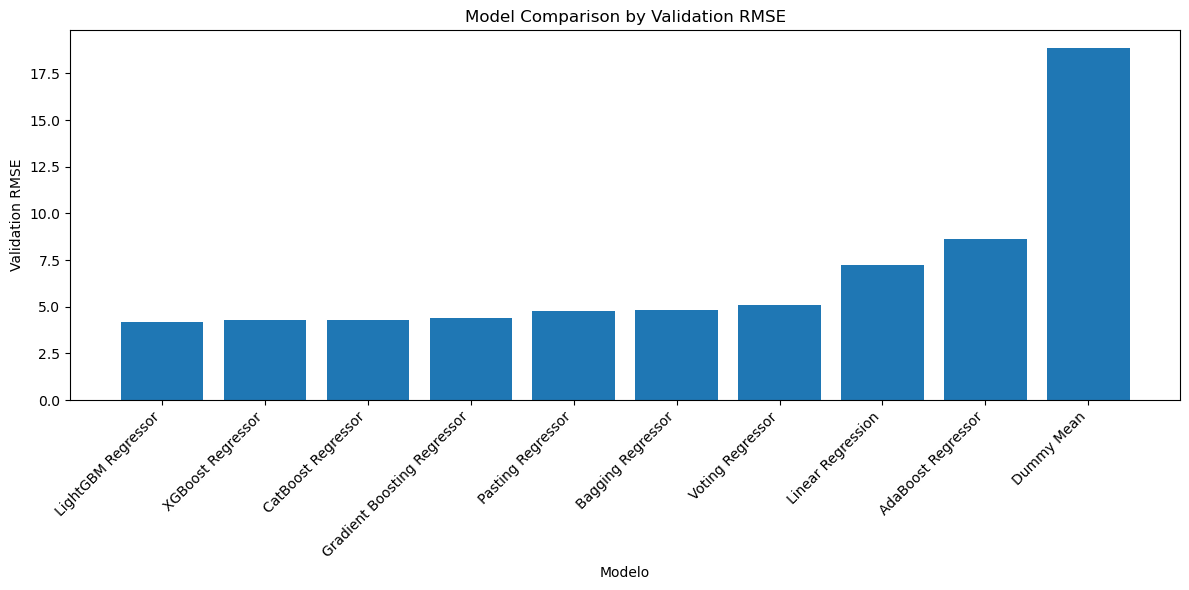

In [78]:
import matplotlib.pyplot as plt

plot_df = final_validation_results_df.sort_values("val_rmse", ascending=True)

plt.figure(figsize=(12, 6))
plt.bar(plot_df["model_name"], plot_df["val_rmse"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Modelo")
plt.ylabel("Validation RMSE")
plt.title("Model Comparison by Validation RMSE")
plt.tight_layout()
plt.show()

Después de entrenar y comparar todos los modelos requeridos, el mejor modelo fue `LightGBM Regressor`.

El criterio de selección fue el menor RMSE sobre el conjunto de validación temporal. Este criterio se usó porque el objetivo del proyecto es predecir `FARE_AMOUNT` con el menor error posible, y el RMSE penaliza con mayor fuerza los errores grandes.

El ranking final en validación fue liderado por:

1. `LightGBM Regressor`
2. `XGBoost Regressor`
3. `CatBoost Regressor`
4. `Gradient Boosting Regressor`

El modelo `LightGBM Regressor` obtuvo el mejor balance entre rendimiento predictivo y costo computacional, con:

- Validation RMSE = `4.1824`
- Validation MAE = `2.1857`
- Validation R² = `0.9446`
- Training time = `10.64` seconds

Por esta razón, `LightGBM Regressor` se selecciona como el modelo candidato para evaluación final en el conjunto de test.

In [83]:
TEST_SAMPLE_PERCENT = 1

test_df = query(f"""
    SELECT *
    FROM ANALYTICS.TEST_FE
    TABLESAMPLE ({TEST_SAMPLE_PERCENT})
""")

print("test_df shape:", test_df.shape)
test_df.head()

C:\Users\encal\AppData\Local\Temp\ipykernel_892\2796719554.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


test_df shape: (360153, 59)


,SERVICE_TYPE,VENDOR_ID,VENDOR_NAME,PICKUP_DATETIME,DROPOFF_DATETIME,PICKUP_DATE,PICKUP_HOUR,DAY_OF_WEEK,MONTH,YEAR,...,IS_LATE_NIGHT,IS_AIRPORT_PU,IS_AIRPORT_DO,IS_AIRPORT_TRIP,SAME_BOROUGH,PU_IS_MANHATTAN,DO_IS_MANHATTAN,RUSH_AIRPORT,LATE_NIGHT_WEEKEND,DIST_X_RUSH
0,yellow,2,"Curb Mobility, LLC",2025-10-07 06:38:41,2025-10-07 06:50:50,2025-10-07,6,2,10,2025,...,0,0,0,0,1,1,1,0,0,0.00
1,yellow,2,"Curb Mobility, LLC",2025-10-07 07:20:07,2025-10-07 07:41:23,2025-10-07,7,2,10,2025,...,0,0,0,0,1,1,1,0,0,3.72
2,yellow,2,"Curb Mobility, LLC",2025-10-07 07:46:35,2025-10-07 07:55:13,2025-10-07,7,2,10,2025,...,0,0,0,0,1,1,1,0,0,1.59
3,yellow,2,"Curb Mobility, LLC",2025-10-07 07:48:41,2025-10-07 07:55:04,2025-10-07,7,2,10,2025,...,0,0,0,0,1,1,1,0,0,1.14
4,yellow,2,"Curb Mobility, LLC",2025-10-07 07:50:29,2025-10-07 08:02:59,2025-10-07,7,2,10,2025,...,0,0,0,0,1,1,1,0,0,1.38


In [84]:
TARGET = "FARE_AMOUNT"

# Separar X/y
X_test = test_df.drop(columns=[c for c in DROP_COLS if c in test_df.columns])
y_test = test_df[TARGET]

# Eliminar las mismas columnas textuales redundantes usadas en train/val
X_test = X_test.drop(columns=[c for c in REDUNDANT_TEXT_COLS if c in X_test.columns])

# Asegurar que X_test tenga exactamente las mismas columnas que X_train
X_test = X_test[X_train.columns]

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# Verificación de consistencia
missing_in_test = [col for col in X_train.columns if col not in X_test.columns]
extra_in_test = [col for col in X_test.columns if col not in X_train.columns]

print("Missing columns in test:", missing_in_test)
print("Extra columns in test:", extra_in_test)

X_test shape: (360153, 31)
y_test shape: (360153,)
Missing columns in test: []
Extra columns in test: []


In [85]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print(f"Evaluating {best_model_name} on TEST_FE sample...")

test_preds = best_model_pipeline.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_mae = mean_absolute_error(y_test, test_preds)
test_r2 = r2_score(y_test, test_preds)

test_metrics = {
    "model_name": best_model_name,
    "test_sample_percent": TEST_SAMPLE_PERCENT,
    "test_rows": len(X_test),
    "test_rmse": test_rmse,
    "test_mae": test_mae,
    "test_r2": test_r2
}

print("Final test metrics:")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test R2: {test_r2:.4f}")

Evaluating LightGBM Regressor on TEST_FE sample...
Final test metrics:
Test RMSE: 4.2789
Test MAE: 2.1978
Test R2: 0.9424


In [86]:
final_model_summary = {
    "model_name": best_model_name,
    "train_rmse": best_result["train_rmse"],
    "val_rmse": best_result["val_rmse"],
    "test_rmse": test_rmse,
    "train_mae": best_result["train_mae"],
    "val_mae": best_result["val_mae"],
    "test_mae": test_mae,
    "train_r2": best_result["train_r2"],
    "val_r2": best_result["val_r2"],
    "test_r2": test_r2,
    "train_time_sec": best_result["train_time_sec"],
    "test_rows": len(X_test),
    "test_sample_percent": TEST_SAMPLE_PERCENT
}

final_model_summary_df = pd.DataFrame([final_model_summary])

final_model_summary_df

,model_name,train_rmse,val_rmse,test_rmse,train_mae,val_mae,test_mae,train_r2,val_r2,test_r2,train_time_sec,test_rows,test_sample_percent
0,LightGBM Regressor,2.477645,4.182432,4.278857,1.347603,2.18568,2.197836,0.952898,0.944611,0.942356,10.640735,360153,1


### Exportaion del modelo

In [87]:
from pathlib import Path

ARTIFACT_DIR = Path("../data/processed")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Artifact directory:", ARTIFACT_DIR.resolve())

Artifact directory: D:\final-project-datamining\data\processed


In [88]:
import joblib

model_path = ARTIFACT_DIR / "best_fare_model_lightgbm_pipeline.pkl"

joblib.dump(best_model_pipeline, model_path)

print("Saved trained pipeline to:")
print(model_path.resolve())

Saved trained pipeline to:
D:\final-project-datamining\data\processed\best_fare_model_lightgbm_pipeline.pkl


In [89]:
validation_results_path = ARTIFACT_DIR / "validation_model_comparison.csv"

final_validation_results_df.to_csv(validation_results_path, index=False)

print("Saved validation model comparison to:")
print(validation_results_path.resolve())

Saved validation model comparison to:
D:\final-project-datamining\data\processed\validation_model_comparison.csv


In [90]:
test_metrics_path = ARTIFACT_DIR / "final_test_metrics.csv"

final_model_summary_df.to_csv(test_metrics_path, index=False)

print("Saved final test metrics to:")
print(test_metrics_path.resolve())

Saved final test metrics to:
D:\final-project-datamining\data\processed\final_test_metrics.csv


In [ ]:
import json
import sys
import sklearn

try:
    import lightgbm as lgb
    lightgbm_version = lgb.__version__
except Exception:
    lightgbm_version = None

model_metadata = {
    "project": "NYC Taxi Trips Fare Prediction",
    "target": TARGET,
    "selected_model": best_model_name,
    "selection_metric": "validation_rmse",
    "model_artifact": model_path.name,
    "artifact_type": "sklearn_pipeline_with_preprocessor_and_lightgbm",
    "data_sources": {
        "train_table": "ANALYTICS.TRAIN_FE",
        "validation_table": "ANALYTICS.VAL_FE",
        "test_table": "ANALYTICS.TEST_FE"
    },
    "data_splits": {
        "train": "2015-2023",
        "validation": "2024",
        "test": "2025"
    },
    "validation_metrics": {
        "train_rmse": float(best_result["train_rmse"]),
        "val_rmse": float(best_result["val_rmse"]),
        "train_mae": float(best_result["train_mae"]),
        "val_mae": float(best_result["val_mae"]),
        "train_r2": float(best_result["train_r2"]),
        "val_r2": float(best_result["val_r2"]),
        "train_time_sec": float(best_result["train_time_sec"])
    },
    "test_metrics": {
        "test_sample_percent": float(TEST_SAMPLE_PERCENT),
        "test_rows": int(len(X_test)),
        "test_rmse": float(test_rmse),
        "test_mae": float(test_mae),
        "test_r2": float(test_r2)
    },
    "lightgbm_best_params": {
        "n_estimators": 200,
        "learning_rate": 0.1,
        "max_depth": 5,
        "num_leaves": 31,
        "min_child_samples": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_alpha": 0.0,
        "reg_lambda": 0.0,
        "objective": "regression",
        "random_state": 42
    },
    "feature_groups": {
        "numeric_features": numeric_features,
        "binary_features": binary_features,
        "categorical_features": categorical_features
    },
    "dropped_columns": DROP_COLS,
    "redundant_text_columns": REDUNDANT_TEXT_COLS,
    "notes": [
        "Model selected using validation RMSE.",
        "Test set was used only once after model selection.",
        "Notebook training used representative samples to respect big-data memory constraints.",
        "Production refactor should move this logic into src/models/train_model.py and src/features/build_features.py."
    ],
    "library_versions": {
        "python": sys.version,
        "scikit_learn": sklearn.__version__,
        "lightgbm": lightgbm_version
    }
}

metadata_path = ARTIFACT_DIR / "best_fare_model_lightgbm_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(model_metadata, f, indent=4)

print("Saved model metadata to:")
print(metadata_path.resolve())

In [92]:
saved_files = sorted([file.name for file in ARTIFACT_DIR.iterdir()])

for file_name in saved_files:
    print(file_name)

.gitkeep
best_fare_model_lightgbm_metadata.json
best_fare_model_lightgbm_pipeline.pkl
final_test_metrics.csv
validation_model_comparison.csv
